# Multi-Agent AI Assistant to Run Exploratory Data Analysis on a File

This notebook is used to create a multi-agent AI assistant that runs a preliminary EDA on a given dataset. The code should generalize to other datasets if in the same format.

I'm starting with an property and casualty dataset. 

The architecture here is a plan-evaluate ReAct loop.

Architecture: Plan → Code-Write → Execute → Evaluate (ReAct loop)

##### Specialist Agents
1. Basic_Summary  – shape, dtypes, nulls, descriptive stats, unique counts, duplicates
2. Grapher        – distributions, frequency bars, numeric correlation heatmap

##### Usage
  Set `filename` in Cell 1 at the top of the notebook, then run.

References:
1. https://medium.com/@mariumaslam499/build-your-own-ai-coding-agent-with-langgraph-040644343e73
2. https://levelup.gitconnected.com/building-17-agentic-ai-patterns-and-their-role-in-large-scale-ai-systems-f4915b5615ce

Updated June 16, 2026

### Define Data File

In [1]:
# Cell 1
# DEFINE THE DATAFILE HERE
# Format of data:
# - column names are first line
# - comma separated values

filename = "~/Documents/Software/DevFile/Property&CasualtyInsurance/finalapi.csv"

MAX_ITERATIONS   = 6   # total code-generation attempts per agent
MAX_ERROR_TRIES  = 3   # max consecutive error-fix retries per agent

### Load Imports

In [2]:
# Cell 2
import os
import sys
import textwrap
import traceback
from typing import List, Optional, TypedDict

import pandas as pd
import matplotlib
import seaborn
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from rich.console import Console   # Console styling
from rich.markdown import Markdown # Render markdown in terminal
from rich.panel import Panel
from rich.syntax import Syntax

# LangChain / LangGraph
from IPython.display import Image, display
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate  # For structuring prompts
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph  # Build a state machine graph

console = Console()      # Instantiate a console object

### Load Env Variables

In [3]:
# Cell 3
# Use getpass to upload OpenAI & LangSmith credentials

load_dotenv()

import getpass

def _set_env(var: str) -> None:
    if not os.environ.get(var):
        console.print(f"[red]{var} not found in environment.[/red]")
        os.environ[var] = getpass.getpass(f"Enter {var}: ")

_set_env("OPENAI_API_KEY")

In [4]:
# Cell 4
# Another way to access the credentials:
# Successful load requires environment variables.
# By default, load_dotenv() looks for .env in the current directory.
# You can specify a path if your .env file is elsewhere:
# load_dotenv(dotenv_path='/path/to/your/.env')

# load_dotenv()

# #Loads the needed env variables into the current notebook session
# OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
# LANGSMITH_API_KEY = os.environ.get("LANGSMITH_API_KEY")
# LANGSMITH_TRACING_V2 = os.environ.get("LANGSMITH_TRACING_V2")
# LANGSMITH_PROJECT = os.environ.get("LANGSMITH_PROJECT")
# LANGSMITH_ENDPOINT = os.environ.get("LANGSMITH_ENDPOINT")


# # Check that the API key is in place
# # Expected behavior: nothing if cell above worked, 
# # otherwise will get a window for entry.
# import getpass

# def _set_env(var: str):
#     if not os.environ.get(var):
#         print("The OPENAI_API_KEY is not found")
#         os.environ[var] = getpass.getpass(f"{var}: ")

# _set_env("OPENAI_API_KEY")

### Define LLM Model

In [5]:
# Cell 6

llm = ChatOpenAI(model="gpt-5-nano",temperature=0)  # swap model string as needed

### PYDANTIC SCHEMAS

In [6]:
# Cell 8
# Use Pydantic to define the schema blueprint.
# Pydantic forces a Large Language Model (LLM) to return its response in a 
# structured, predictable format instead of free-form text.

class Planner(BaseModel):
    """Structured output: the ordered list of specialist agents to call."""
    steps: List[str] = Field(
        description=(
            "Ordered list of specialist agent names to execute. "
            "Each element must be exactly one of: 'Basic_Summary', 'Grapher'."
        )
    )
    reasoning: str = Field(description="Brief justification for the chosen agents and order.")
    step_description: List[str] = Field(
        description=(
            "One instruction string per agent in `steps`. "
            "Each string is a self-contained, concise task description for that agent."
        )
    )


class CodeObject(BaseModel):
    """Structured output: a runnable Python code solution."""
    preamble:  str = Field(description="Plain-English description of what the code does.")
    imports:   str = Field(description="All import statements, one per line, no extra text.")
    code:      str = Field(description="Executable code body (no import statements here).")



### Define the Graph State

In [7]:
# Cell 10
# Define a Class Object
# This allows us to have structured code that follows consistent format with a description, 
# import statements, and executable code.

class GraphState(TypedDict):
    # ── set once by the user ──────────────────────────────────────────────────
    user_request:       str
    filename:           str          # path to the CSV

    # ── set by the planner ───────────────────────────────────────────────────
    next_agent_to_call: List[str]    # remaining agents (pop from front each loop)
    step_description:   List[str]    # parallel list of per-agent instructions

    # ── per-agent loop state ─────────────────────────────────────────────────
    messages:           List         # running chat history for the *current* agent
    generation:         Optional[CodeObject]
    iterations:         int
    error_iterations:   int
    error:              str          # "yes" | "no"
    next_step:          str          # "continue" | "end"

    # ── accumulated outputs ───────────────────────────────────────────────────
    completed_outputs:  List[str]    # printed results collected from exec()



### Define the Specialist Tasks

In [8]:
# Cell 12
# These strings reach the code-writer so it knows exactly what to produce.

SPECIALIST_DEFINITIONS = {
    "Basic_Summary": (
        "Write Python code that performs the following on the DataFrame already loaded "
        "into a variable called `df`:\n"
        "1. Number of rows and columns (shape).\n"
        "2. Column names and their data types.\n"
        "3. Number of null values per column.\n"
        "4. For every NUMERIC column: count, mean, std, min, 25th-pct, 50th-pct (median), "
        "75th-pct, max.  Display as a transposed DataFrame for readability.\n"
        "5. For every CATEGORICAL / OBJECT column: number of unique values and the "
        "top-10 most frequent values with their counts.\n"
        "6. Count of exact duplicate rows.\n"
        "Print each section with a clearly labelled header. "
        "Do NOT reload the CSV – `df` is already defined."
    ),
    "Grapher": (
        "Write Python code that creates the following visualisations using matplotlib / seaborn "
        "on the DataFrame already loaded into a variable called `df`:\n"
        "1. Histogram + KDE for every numeric column.\n"
        "2. Horizontal bar chart of value-counts for every categorical (object) column "
        "(top 15 values if more than 15).\n"
        "3. Correlation heatmap of all numeric columns.\n"
        "4. Pairplot (scatter-matrix) of numeric columns (skip if > 10 numeric columns).\n"
        "Use matplotlib.pyplot.show() to display each figure inline after creating it. "
        "Call plt.tight_layout() before plt.show(). "
        "Do NOT save any files. Do NOT call plt.savefig(). "
        "Do NOT reload the CSV – `df` is already defined."
    ),
}


### Define the Nodes

In [9]:
# Cell 14
# Node 1 - Planner

def planner_node(state: GraphState) -> GraphState:
    """
    Reads the user request and decides which specialist agents to call
    and in what order.
    """
    console.rule("[bold blue]🧠  Planner")

    specialist_block = "\n".join(
        f"  • {name}: {desc[:120]}…"          # truncate for prompt brevity
        for name, desc in SPECIALIST_DEFINITIONS.items()
    )

    prompt = ChatPromptTemplate.from_template(
        "You are an expert planner for a multi-agent EDA system.\n\n"
        "Available specialists:\n{specialists}\n\n"
        "User request:\n{user_request}\n\n"
        "Choose ONE OR BOTH specialists needed to satisfy the request, "
        "in the order they should run. "
        "Basic_Summary must always precede Grapher if both are chosen.\n\n"
        "IMPORTANT: `step_description` must contain EXACTLY one entry per agent in `steps`. "
        "If you choose 2 agents, you must provide exactly 2 step descriptions — "
        "one for each agent, in the same order. Never combine them into one string."
    )

    planner_llm = llm.with_structured_output(Planner)
    plan: Planner = (prompt | planner_llm).invoke(
        {"specialists": specialist_block, "user_request": state["user_request"]}
    )

    console.print(f"[yellow]Plan:[/yellow] {plan.steps}")
    console.print(f"[italic]{plan.reasoning}[/italic]")

    return {
        **state,
        "next_agent_to_call": plan.steps,
        "step_description":   plan.step_description,
        # reset per-agent loop state
        "messages":           [],
        "generation":         None,
        "iterations":         0,
        "error_iterations":   0,
        "error":              "no",
        "next_step":          "continue",
        "completed_outputs":  [],
    }


In [10]:
# Cell 15
# Node 2 - Code Writer

CODE_SYSTEM_PROMPT = """\
You are an expert Python data-science assistant.
Your ONLY job is to write clean, runnable Python code.

Rules:
- The variable `df` already holds the loaded pandas DataFrame – do NOT reload the CSV.
- Split your answer into exactly three sections labelled ###1, ###2, ###3:
    ###1  Preamble  (plain English description, no code)
    ###2  Imports   (import statements only)
    ###3  Code      (executable body, no import statements)
- No markdown fences, no extra commentary outside the three sections.
"""

def code_writer_node(state: GraphState) -> GraphState:
    """
    Generates (or repairs) Python code for the *current* specialist agent.
    The current agent is always state['next_agent_to_call'][0].
    """
    agent_name = state["next_agent_to_call"][0]
    task       = state["step_description"][0]
    messages   = list(state["messages"])     # copy
    error      = state["error"]
    iterations = state["iterations"]

    console.rule(f"[bold cyan]✍️  Code Writer  [{agent_name}]  iter={iterations+1}")

    if error == "yes":
        # Ask the model to fix the previous attempt
        messages.append(HumanMessage(content=(
            "The code above raised an error. "
            "Fix it and return the corrected ###1 / ###2 / ###3 sections."
        )))
    else:
        # First attempt for this agent
        messages = [
            SystemMessage(content=CODE_SYSTEM_PROMPT),
            HumanMessage(content=(
                f"Task for specialist '{agent_name}':\n{task}\n\n"
                "Remember: `df` is already defined. Write only the three labelled sections."
            )),
        ]

    raw_response: AIMessage = llm.invoke(messages)
    raw_text = raw_response.content

    # ── Parse the three sections ──────────────────────────────────────────────
    code_obj = _parse_code_sections(raw_text)

    messages.append(raw_response)   # add AI reply to history

    console.print(Panel(Syntax(code_obj.imports + "\n" + code_obj.code,
                               "python", theme="monokai", line_numbers=True),
                        title="Generated Code", expand=False))

    return {
        **state,
        "messages":   messages,
        "generation": code_obj,
        "iterations": iterations + 1,
        "error":      "no",    # reset; execute node will set "yes" if needed
    }


def _parse_code_sections(text: str) -> CodeObject:
    """
    Extract preamble / imports / code from a ###1 / ###2 / ###3 delimited response.
    Falls back gracefully if the model ignores the format.
    """
    sections = {"1": "", "2": "", "3": ""}
    current  = None

    for line in text.splitlines():
        stripped = line.strip()
        if stripped.startswith("###1"):
            current = "1"
            continue
        elif stripped.startswith("###2"):
            current = "2"
            continue
        elif stripped.startswith("###3"):
            current = "3"
            continue
        if current:
            sections[current] += line + "\n"

    # If parsing failed, treat the whole response as the code body
    if not sections["3"].strip() and not sections["2"].strip():
        return CodeObject(
            preamble="(Could not parse sections – full response used as code)",
            imports="",
            code=text,
        )

    return CodeObject(
        preamble=sections["1"].strip(),
        imports=sections["2"].strip(),
        code=sections["3"].strip(),
    )



In [11]:
# Cell 16
# Node 3 - Code Executor

def code_executor_node(state: GraphState) -> GraphState:
    console.rule("[bold green]⚙️  Code Executor")

    code_obj        = state["generation"]
    messages        = list(state["messages"])
    error_iterations = state["error_iterations"]
    completed       = list(state["completed_outputs"])

    full_code = (code_obj.imports or "") + "\n" + (code_obj.code or "")

    # Pre-load df and configure matplotlib for inline notebook display
    import matplotlib
    matplotlib.use("module://matplotlib_inline.backend_inline")
    import matplotlib.pyplot as plt

    exec_globals: dict = {
        "df":  _load_dataframe(state["filename"]),
        "plt": plt,       # share the same plt instance so show() renders inline
    }

    import io
    captured = io.StringIO()
    old_stdout = sys.stdout
    sys.stdout = captured

    try:
        exec(full_code, exec_globals)
        sys.stdout = old_stdout
        output = captured.getvalue()
        console.print("[green]✅ Execution succeeded.[/green]")
        if output:
            console.print(Panel(output, title="Execution Output", expand=False))
        completed.append(output or "(no printed output)")
        return {
            **state,
            "error":             "no",
            "next_step":         "end",
            "messages":          messages,
            "error_iterations":  error_iterations,
            "completed_outputs": completed,
        }
    except Exception as exc:
        sys.stdout = old_stdout
        tb = traceback.format_exc()
        console.print(f"[red]❌ Execution error:[/red]\n{tb}")
        messages.append(HumanMessage(content=f"Execution raised an exception:\n{tb}"))
        return {
            **state,
            "error":             "yes",
            "next_step":         "continue",
            "messages":          messages,
            "error_iterations":  error_iterations + 1,
            "completed_outputs": completed,
        }


In [12]:
# Cell 17
# Node 4 - Agent Router (decides: retry same agent | advance to next | finish)

def agent_router_node(state: GraphState) -> GraphState:
    if state["next_step"] == "end":
        remaining_agents = state["next_agent_to_call"][1:]
        remaining_descs  = state["step_description"][1:]

        # Safety: if descriptions ran out, pad with the specialist definition
        if remaining_agents and not remaining_descs:
            remaining_descs = [
                SPECIALIST_DEFINITIONS.get(remaining_agents[0], 
                    f"Perform the {remaining_agents[0]} analysis on df.")
            ]

        return {
            **state,
            "next_agent_to_call": remaining_agents,
            "step_description":   remaining_descs,
            "messages":           [],
            "generation":         None,
            "iterations":         0,
            "error_iterations":   0,
            "error":              "no",
            "next_step":          "continue",
        }
    return state   # still retrying → don't pop



In [13]:
# Cell 18
# Conditional Edge Function

def decide_next(state: GraphState) -> str:
    """
    Returns the name of the next graph node:
      "write_code"   – retry: re-enter code writer for the same agent
      "route_agents" – current agent succeeded; check if more agents remain
      "end"          – hard stop (too many iterations or errors)
    """
    iterations      = state["iterations"]
    error_iters     = state["error_iterations"]
    next_step       = state["next_step"]

    # Hard stop conditions
    if iterations >= MAX_ITERATIONS or error_iters >= MAX_ERROR_TRIES:
        console.print("[red]⚠️  Max iterations or errors reached. Stopping.[/red]")
        return "end"

    if next_step == "end":
        # Current agent finished; check whether more remain
        remaining = state["next_agent_to_call"][1:]   # peek at what's left after pop
        if remaining:
            return "route_agents"
        else:
            return "end"

    # Not done yet → fix / regenerate code
    return "write_code"



In [14]:
# Cell 19 
# Node 5 - Final Report

def final_report_node(state: GraphState) -> GraphState:
    """Prints a summary of all collected outputs."""
    console.rule("[bold magenta]📋  Final Report")
    for i, output in enumerate(state["completed_outputs"], 1):
        console.print(Panel(output, title=f"Agent {i} Output", expand=False))
    return state



In [15]:
# Cell 20
# Helper - load the dataframe (called inside the executor namespace)

def _load_dataframe(path: str) -> pd.DataFrame:
    expanded = os.path.expanduser(path)
    return pd.read_csv(expanded)

### Build the Graph

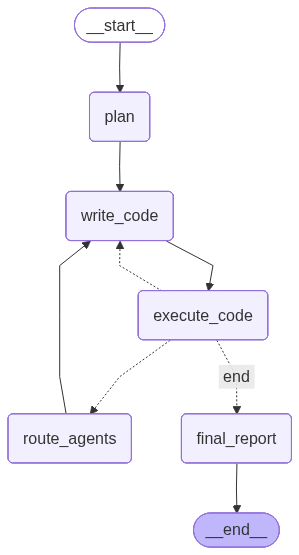

In [16]:
# Cell 21
# 

def build_graph() -> StateGraph:
    graph = StateGraph(GraphState)

    # ── nodes ────────────────────────────────────────────────────────────────
    graph.add_node("plan",         planner_node)
    graph.add_node("write_code",   code_writer_node)
    graph.add_node("execute_code", code_executor_node)
    graph.add_node("route_agents", agent_router_node)
    graph.add_node("final_report", final_report_node)

    # ── static edges ─────────────────────────────────────────────────────────
    graph.add_edge(START,          "plan")
    graph.add_edge("plan",         "write_code")
    graph.add_edge("write_code",   "execute_code")
    graph.add_edge("route_agents", "write_code")   # next agent → fresh code write
    graph.add_edge("final_report", END)

    # ── conditional edges ─────────────────────────────────────────────────────
    graph.add_conditional_edges(
        "execute_code",
        decide_next,
        {
            "write_code":   "write_code",    # retry current agent
            "route_agents": "route_agents",  # advance to next agent
            "end":          "final_report",  # all done
        },
    )

    return graph

# View graph
graph   = build_graph()
memory  = MemorySaver()
app     = graph.compile(checkpointer=memory)
try:
        display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
        print("Something went wrong. Cannot display the graph. Probably because not executing in a notebook or graphviz is unavailable.")
        pass   # Skip if not in a notebook / graphviz unavailable - but give message

### Execute

───────────────────────────────────────────── 🚀  Starting EDA Agent ──────────────────────────────────────────────

─────────────────────────────────────────────────── 🧠  Planner ───────────────────────────────────────────────────

Plan: ['Basic_Summary', 'Grapher']

To satisfy a complete exploratory data analysis, we should first compute comprehensive numeric/categorical 
summaries and metadata (shape, dtypes, nulls, duplicates, and descriptive statistics) so the dataset's structure is
clear. Then we generate visualizations (distributions, frequencies, and correlations) to support interpretation and
reporting. Running Basic_Summary first ensures the statistics are readily available for any follow-up visuals and 
keeps concerns separated between data characterization and visualization.

───────────────────────────────────── ✍️  Code Writer  [Basic_Summary]  iter=1 ─────────────────────────────────────

...

✅ Execution succeeded.

──────────────────────────────────────────────── 📋  Final Report ─────────────────────────────────────────────────

╭──────────────────────────────────────────────── Agent 1 Output ─────────────────────────────────────────────────╮
│ {'shape': (213328, 49), 'dtypes': {'AGENCY_ID': 'int64', 'PRIMARY_AGENCY_ID': 'int64', 'PROD_ABBR': 'object',   │
│ 'PROD_LINE': 'object', 'STATE_ABBR': 'object', 'STAT_PROFILE_DATE_YEAR': 'int64', 'RETENTION_POLY_QTY':         │
│ 'int64', 'POLY_INFORCE_QTY': 'int64', 'PREV_POLY_INFORCE_QTY': 'int64', 'NB_WRTN_PREM_AMT': 'float64',          │
│ 'WRTN_PREM_AMT': 'float64', 'PREV_WRTN_PREM_AMT': 'float64', 'PRD_ERND_PREM_AMT': 'float64',                    │
│ 'PRD_INCRD_LOSSES_AMT': 'float64', 'MONTHS': 'int64', 'RETENTION_RATIO': 'float64', 'LOSS_RATIO': 'float64',    │
│ 'LOSS_RATIO_3YR': 'float64', 'GROWTH_RATE_3YR': 'float64', 'AGENCY_APPOINTMENT_YEAR': 'int64',                  │
│ 'ACTIVE_PRODUCERS': 'int64', 'MAX_AGE': 'int64', 'MIN_AGE': 'int64', 'VENDOR_IND': 'object', 'VENDOR':          │
│ 'object', 'PL_START_YEAR': 'int64', 'PL_END_YEAR': 'int64', 'COMMISIONS_START_YEAR': 'int64',                   │
│ 'COMMISIONS_END_YEAR': 'int64', 'CL_START_YEAR': 'int64', 'CL_END_YEAR': 'int64', 'ACTIVITY_NOTES_START_YEAR':  │
│ 'int64', 'ACTIVITY_NOTES_END_YEAR': 'int64', 'CL_BOUND_CT_MDS': 'int64', 'CL_QUO_CT_MDS': 'int64',              │
│ 'CL_BOUND_CT_SBZ': 'int64', 'CL_QUO_CT_SBZ': 'int64', 'CL_BOUND_CT_eQT': 'int64', 'CL_QUO_CT_eQT': 'int64',     │
│ 'PL_BOUND_CT_ELINKS': 'int64', 'PL_QUO_CT_ELINKS': 'int64', 'PL_BOUND_CT_PLRANK': 'int64', 'PL_QUO_CT_PLRANK':  │
│ 'int64', 'PL_BOUND_CT_eQTte': 'int64', 'PL_QUO_CT_eQTte': 'int64', 'PL_BOUND_CT_APPLIED': 'int64',              │
│ 'PL_QUO_CT_APPLIED': 'int64', 'PL_BOUND_CT_TRANSACTNOW': 'int64', 'PL_QUO_CT_TRANSACTNOW': 'int64'},            │
│ 'null_counts': {'AGENCY_ID': 0, 'PRIMARY_AGENCY_ID': 0, 'PROD_ABBR': 0, 'PROD_LINE': 0, 'STATE_ABBR': 0,        │
│ 'STAT_PROFILE_DATE_YEAR': 0, 'RETENTION_POLY_QTY': 0, 'POLY_INFORCE_QTY': 0, 'PREV_POLY_INFORCE_QTY': 0,        │
│ 'NB_WRTN_PREM_AMT': 0, 'WRTN_PREM_AMT': 0, 'PREV_WRTN_PREM_AMT': 0, 'PRD_ERND_PREM_AMT': 0,                     │
│ 'PRD_INCRD_LOSSES_AMT': 0, 'MONTHS': 0, 'RETENTION_RATIO': 0, 'LOSS_RATIO': 0, 'LOSS_RATIO_3YR': 0,             │
│ 'GROWTH_RATE_3YR': 0, 'AGENCY_APPOINTMENT_YEAR': 0, 'ACTIVE_PRODUCERS': 0, 'MAX_AGE': 0, 'MIN_AGE': 0,          │
│ 'VENDOR_IND': 0, 'VENDOR': 0, 'PL_START_YEAR': 0, 'PL_END_YEAR': 0, 'COMMISIONS_START_YEAR': 0,                 │
│ 'COMMISIONS_END_YEAR': 0, 'CL_START_YEAR': 0, 'CL_END_YEAR': 0, 'ACTIVITY_NOTES_START_YEAR': 0,                 │
│ 'ACTIVITY_NOTES_END_YEAR': 0, 'CL_BOUND_CT_MDS': 0, 'CL_QUO_CT_MDS': 0, 'CL_BOUND_CT_SBZ': 0, 'CL_QUO_CT_SBZ':  │
│ 0, 'CL_BOUND_CT_eQT': 0, 'CL_QUO_CT_eQT': 0, 'PL_BOUND_CT_ELINKS': 0, 'PL_QUO_CT_ELINKS': 0,                    │
│ 'PL_BOUND_CT_PLRANK': 0, 'PL_QUO_CT_PLRANK': 0, 'PL_BOUND_CT_eQTte': 0, 'PL_QUO_CT_eQTte': 0,                   │
│ 'PL_BOUND_CT_APPLIED': 0, 'PL_QUO_CT_APPLIED': 0, 'PL_BOUND_CT_TRANSACTNOW': 0, 'PL_QUO_CT_TRANSACTNOW': 0},    │
│ 'numeric_describe': {'AGENCY_ID': {'count': 213328.0, 'mean': 4978.964158478962, 'std': 2928.027641546782,      │
│ 'min': 3.0, '25%': 2366.0, '50%': 4976.0, '75%': 7589.0, 'max': 9998.0}, 'PRIMARY_AGENCY_ID': {'count':         │
│ 213328.0, 'mean': 21840.982205805147, 'std': 36410.35543967823, 'min': 3.0, '25%': 2788.0, '50%': 6110.0,       │
│ '75%': 9285.0, 'max': 99999.0}, 'STAT_PROFILE_DATE_YEAR': {'count': 213328.0, 'mean': 2010.1917376059403,       │
│ 'std': 3.1291080760803283, 'min': 2005.0, '25%': 2008.0, '50%': 2010.0, '75%': 2013.0, 'max': 2015.0},          │
│ 'RETENTION_POLY_QTY': {'count': 213328.0, 'mean': 158.63452523813095, 'std': 718.7662950402141, 'min': 0.0,     │
│ '25%': 0.0, '50%': 0.0, '75%': 24.0, 'max': 21979.0}, 'POLY_INFORCE_QTY': {'count': 213328.0, 'mean':           │
│ 175.6169185479637, 'std': 774.6408596685181, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 30.0, 'max': 22968.0},  │
│ 'PREV_POLY_INFORCE_QTY': {'count': 213328.0, 'mean': 6

╭── Agent 2 Output ───╮
│ (no printed output) │
╰─────────────────────╯

──────────────────────────────────────────────── ✅  EDA Complete ─────────────────────────────────────────────────

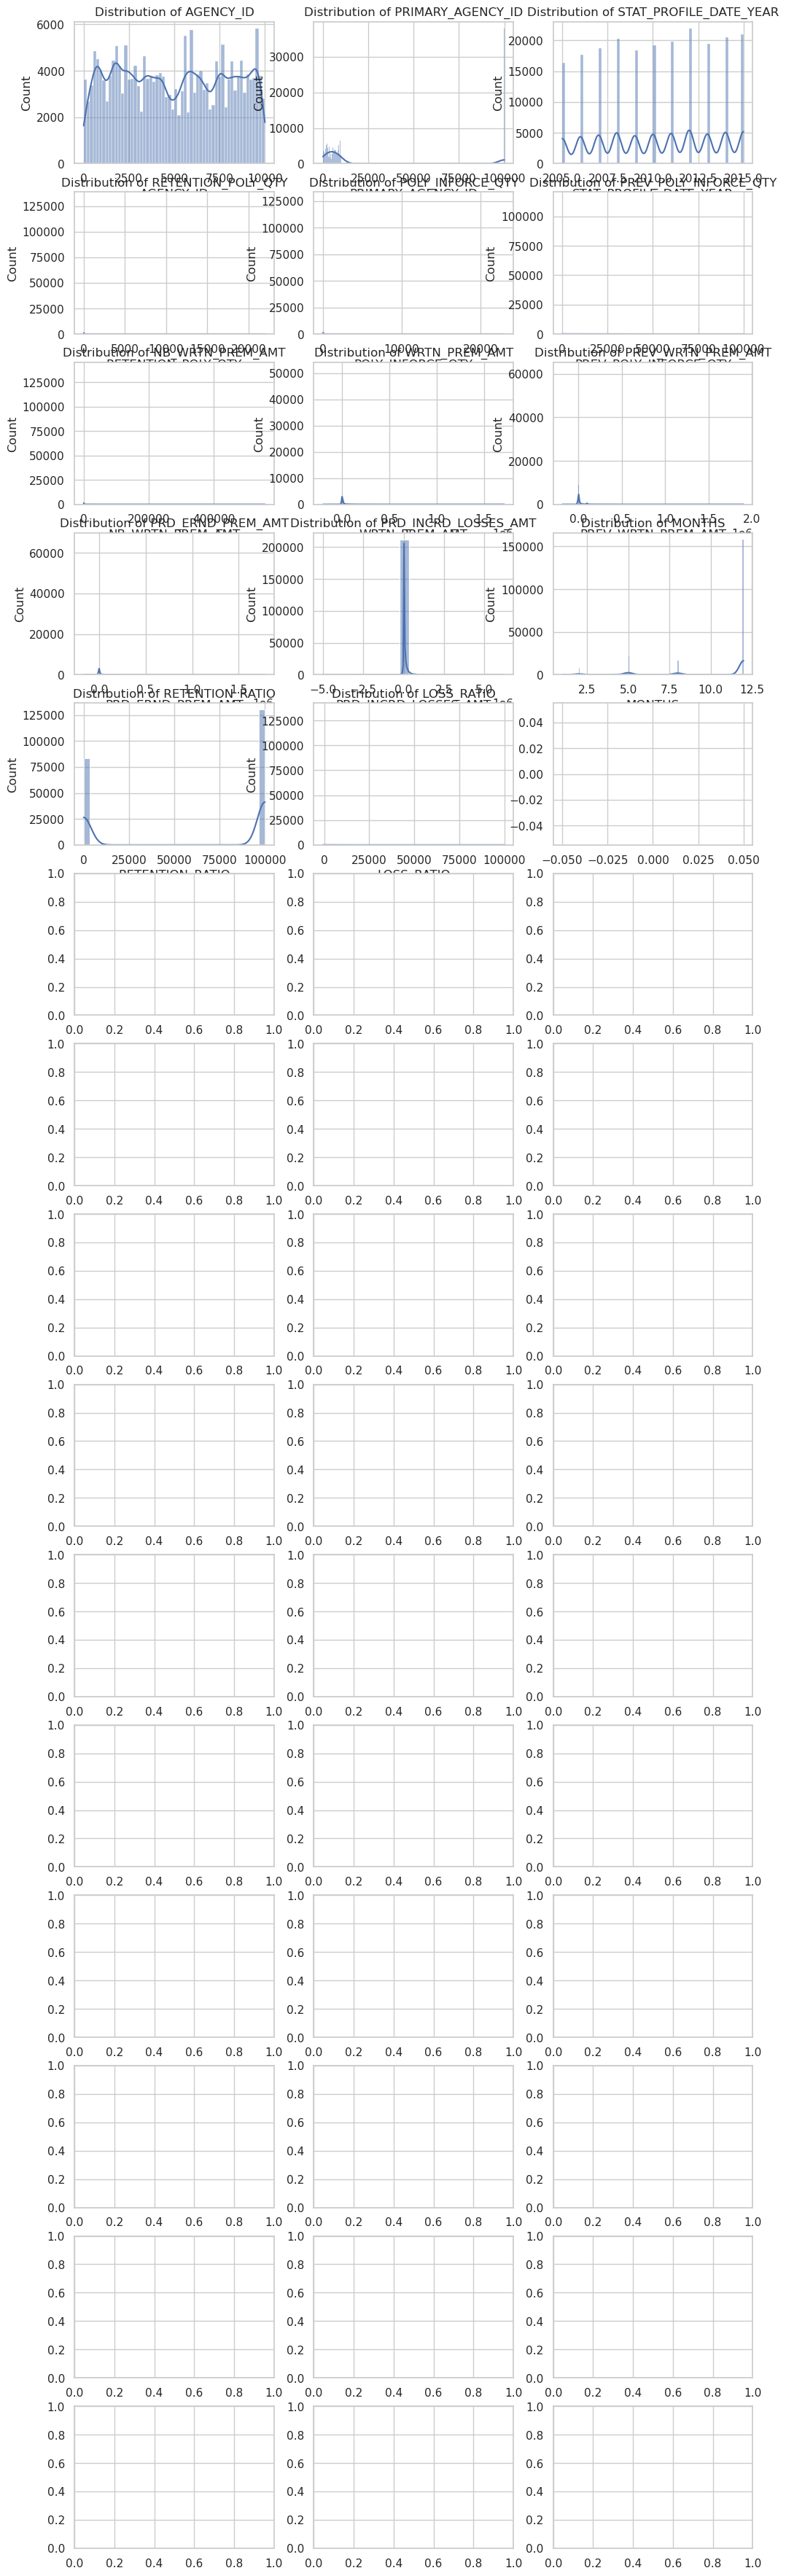

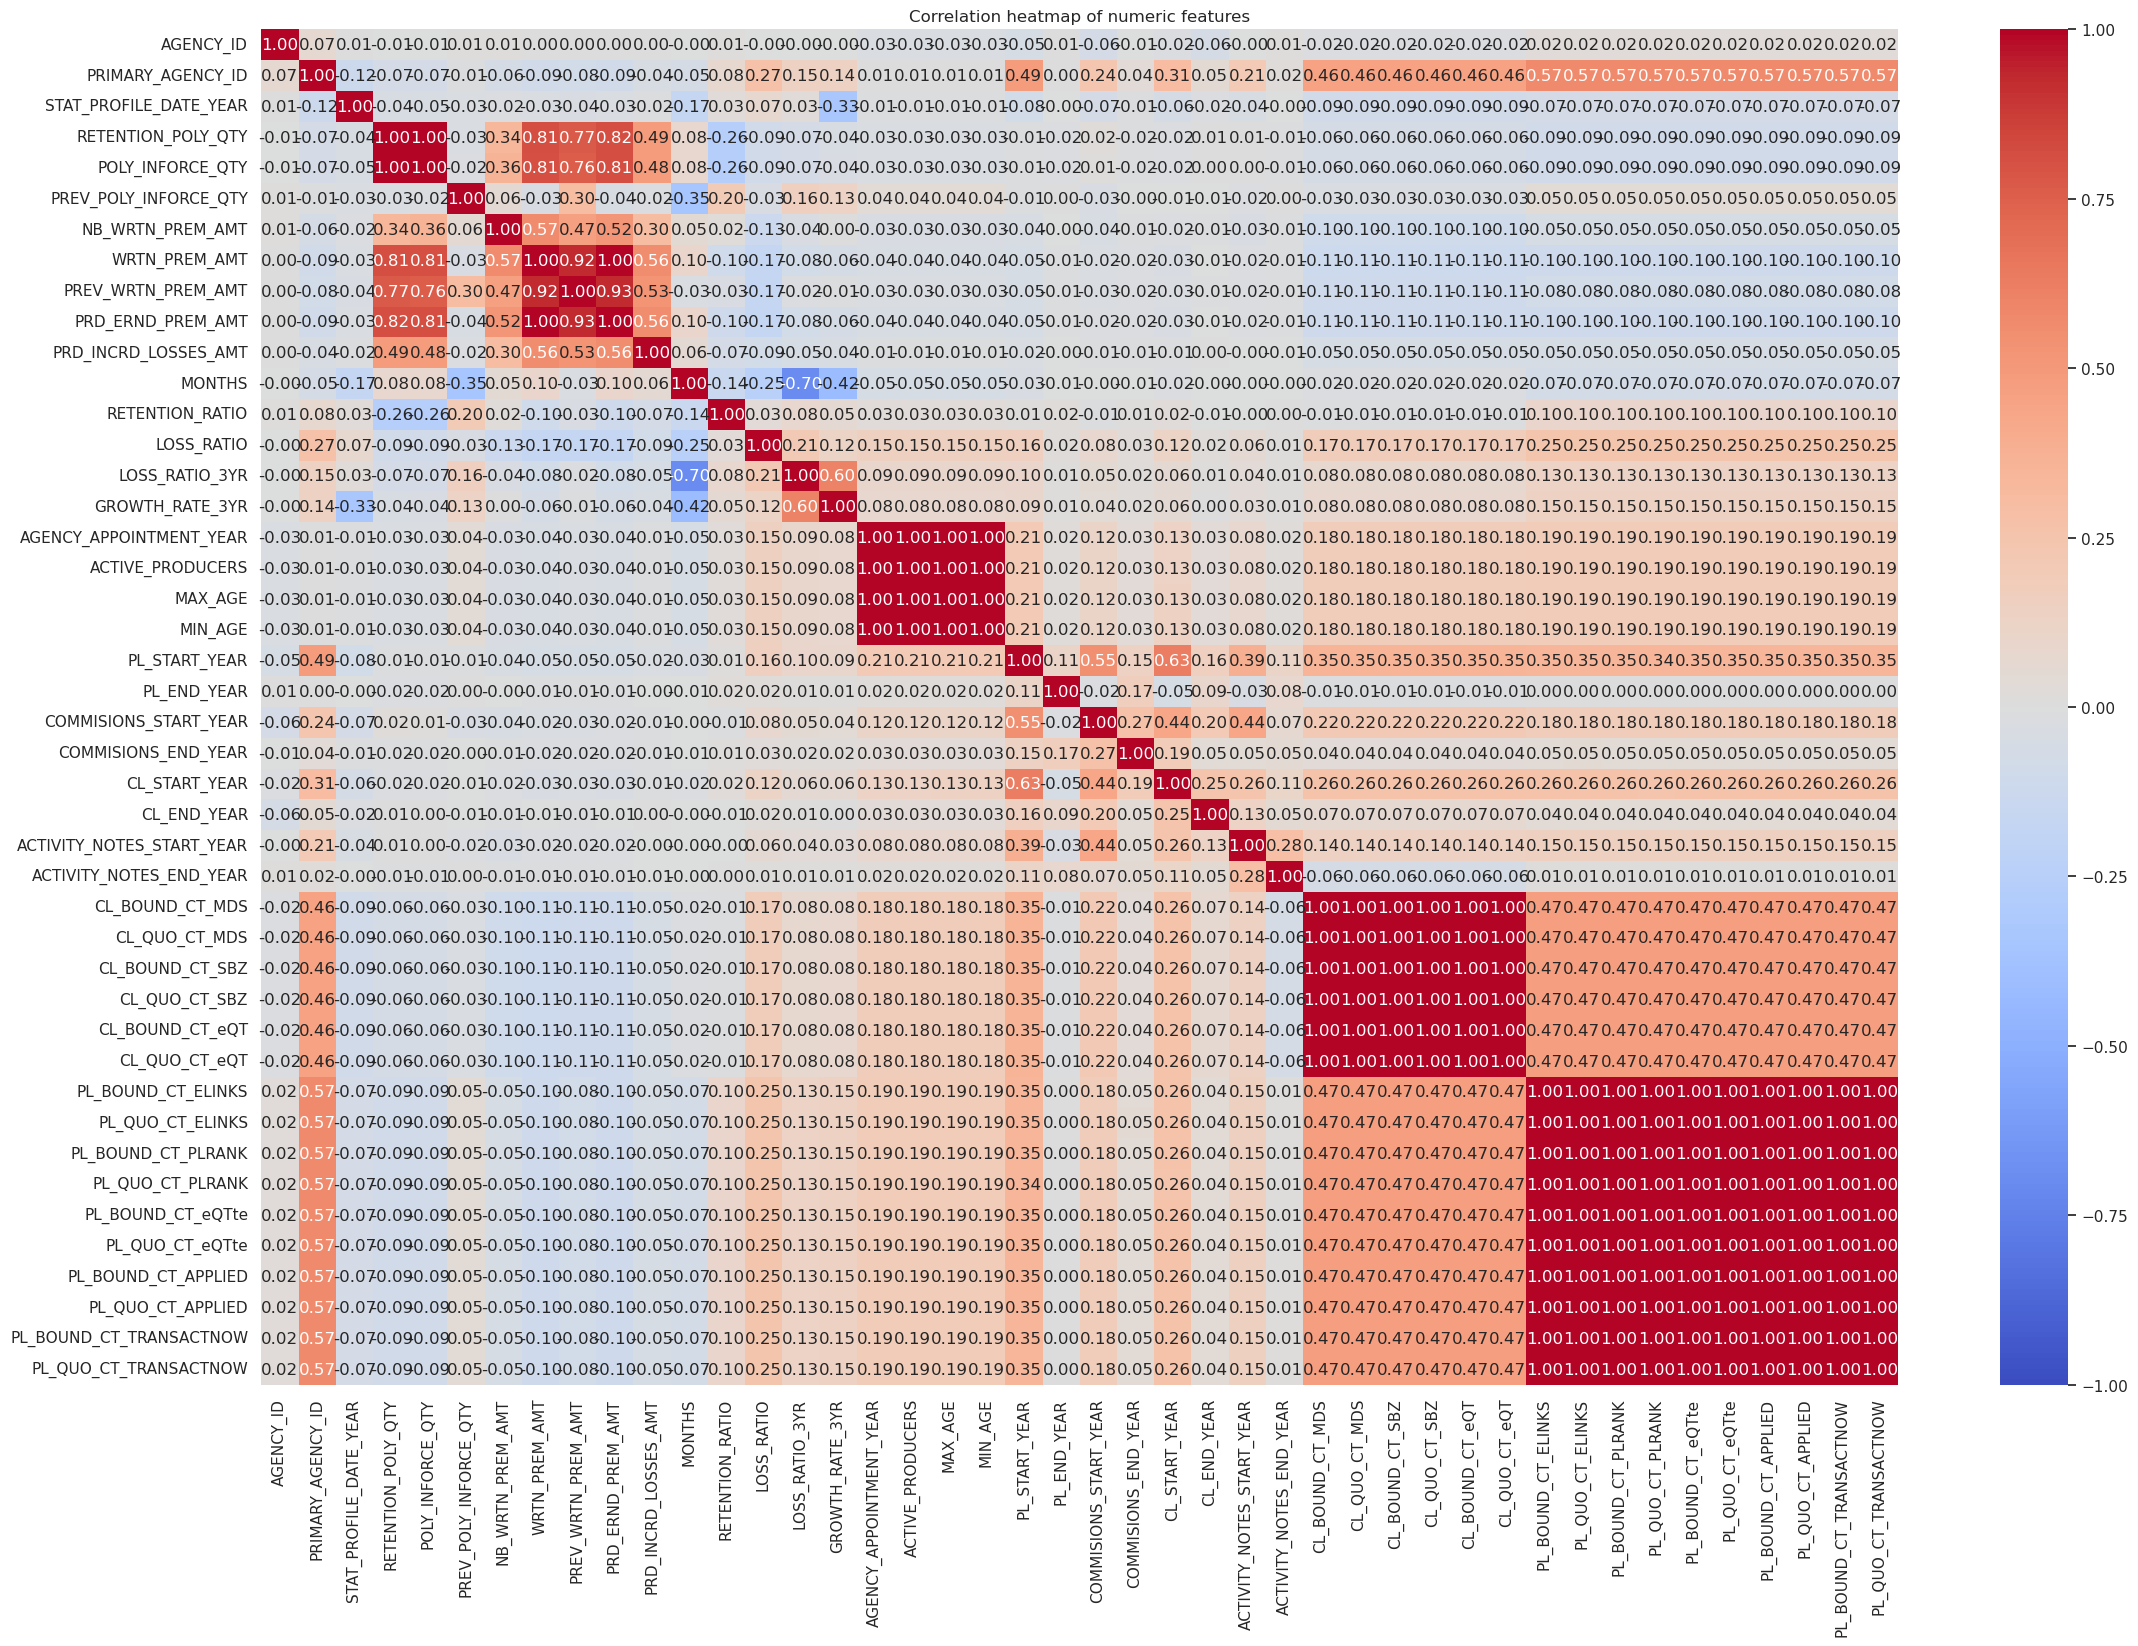

In [17]:
# Cell 23

def run_eda(filepath: str, user_question: Optional[str] = None) -> None:
    """
    Main entry point.

    Parameters
    ----------
    filepath      : path to the CSV file to analyse
    user_question : optional custom question; defaults to a full EDA request
    """
    if user_question is None:
        user_question = (
            f"Perform a complete exploratory data analysis on the dataset at '{filepath}'. "
            "I need: the number of rows and columns; all column names and their data types; "
            "null-value counts per column; descriptive statistics (count, mean, std, min, "
            "25th-pct, median, 75th-pct, max) for every numeric column; a unique-value count "
            "for every categorical column with the top-10 most frequent values; "
            "and the total number of duplicate rows. "
            "Also produce visualisation charts for distributions, frequencies, and correlations."
        )


    thread  = {"configurable": {"thread_id": "eda-run-1"}}
    initial_state: GraphState = {
        "user_request":       user_question,
        "filename":           filepath,
        "next_agent_to_call": [],
        "step_description":   [],
        "messages":           [],
        "generation":         None,
        "iterations":         0,
        "error_iterations":   0,
        "error":              "no",
        "next_step":          "continue",
        "completed_outputs":  [],
    }

    console.rule("[bold white]🚀  Starting EDA Agent")
    app.invoke(initial_state, config=thread)
    console.rule("[bold white]✅  EDA Complete")


# ── Run ───────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    run_eda(filename)